<a href="https://colab.research.google.com/github/rohitudhwani/ecommerce_analytics/blob/main/churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

In [3]:
file_path = '/content/drive/MyDrive/eCommerce Churn Prediction/data/online_retail_II.xlsx'
df1 = pd.read_excel(file_path, sheet_name='Year 2009-2010', engine='openpyxl')
df2 = pd.read_excel(file_path, sheet_name='Year 2010-2011', engine='openpyxl')
df = pd.concat([df1, df2], ignore_index=True)
print(f"\nCombined dataset shape: {df.shape}")


Combined dataset shape: (1067371, 8)


# EDA

## Basic EDA

In [8]:
print("\nColumn Types")
print(df.dtypes)
print("\nFirst 5 Rows")
display(df.head())
print("\nMissing Values")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print("\nBasic Stats")
print(f"Total transactions       : {len(df):,}")
print(f"Unique invoices          : {df['Invoice'].nunique():,}")
print(f"Unique customers         : {df['Customer ID'].nunique():,}")
print(f"Unique products          : {df['StockCode'].nunique():,}")
print(f"Date range               : {df['InvoiceDate'].min()} - {df['InvoiceDate'].max()}")
print(f"Countries represented    : {df['Country'].nunique()}")
print(f"Cancellations (C prefix) : {df['Invoice'].astype(str).str.startswith('C').sum():,}")
print("\n Stats")
display(df.describe())


Column Types
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

First 5 Rows


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Missing Values
             Missing Count  Missing %
Description           4382       0.41
Customer ID         243007      22.77

Basic Stats
Total transactions       : 1,067,371
Unique invoices          : 53,628
Unique customers         : 5,942
Unique products          : 5,305
Date range               : 2009-12-01 07:45:00 - 2011-12-09 12:50:00
Countries represented    : 43
Cancellations (C prefix) : 19,494

 Stats


,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


## Cleaning

In [16]:
df_clean = df.copy()
# getting rid of cancelled orders
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
# getting rid of null cust ids
df_clean = df_clean.dropna(subset=['Customer ID'])
# getting rid of negative quantities and prices
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
# ensuring cust id is string type
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)
# ensuring invoice date is datetime col tupe
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
# adding revenue column to calculate total sale for each row (price*quantity)
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
print(f"\nClean dataset shape: {df_clean.shape}")
print("-- Changes made --")
print(f"Original Dataset Size: {len(df)} versus the Cleaned Dataset: {len(df_clean)}")
print(f"Original Dataset Shape: {df.shape} versus the Cleaned Dataset: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean):,}")


Clean dataset shape: (805549, 9)
-- Changes made --
Original Dataset Size: 1067371 versus the Cleaned Dataset: 805549
Original Dataset Shape: (1067371, 8) versus the Cleaned Dataset: (805549, 9)
Rows removed: 261,822


## Basic EDA Plots

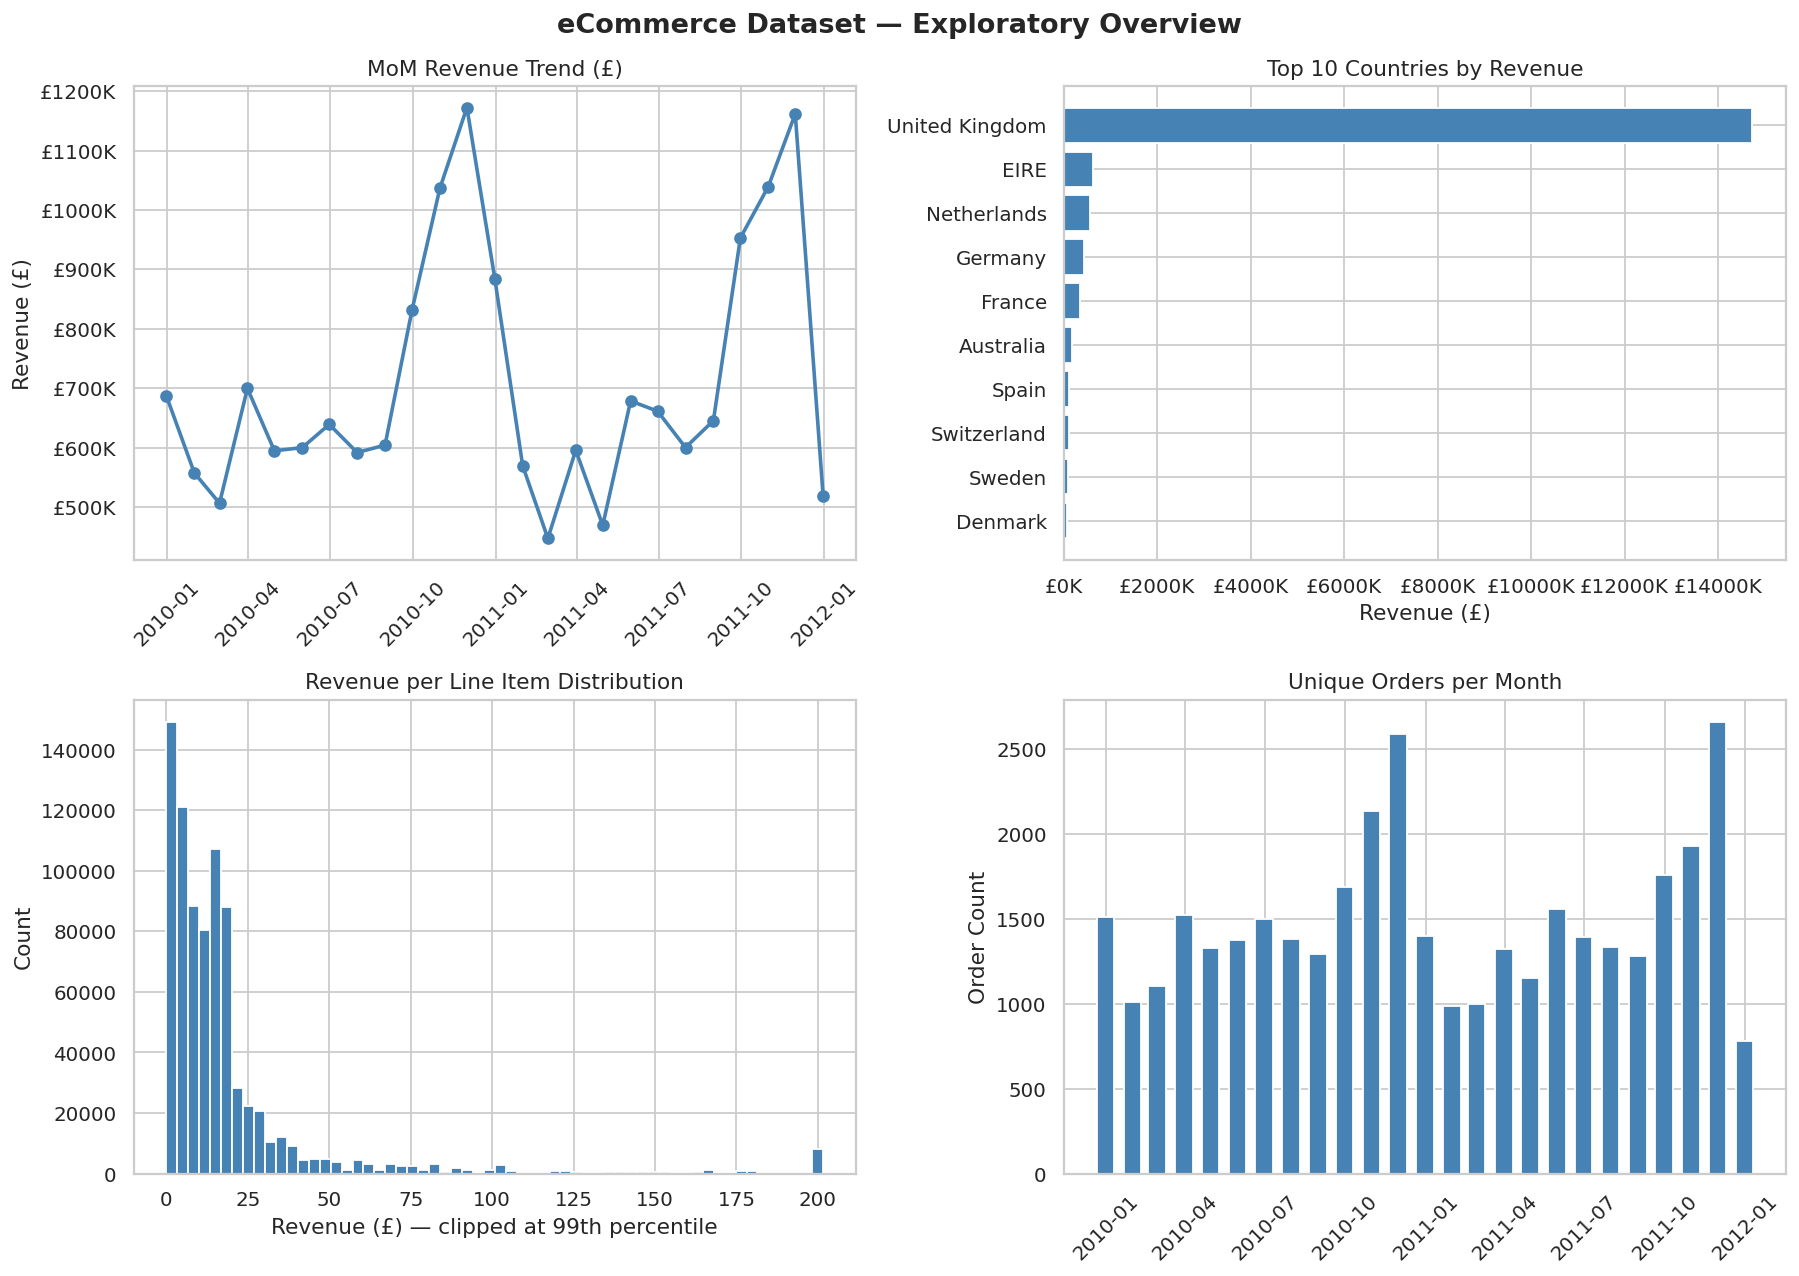

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('eCommerce Dataset — Exploratory Overview', fontsize=15, fontweight='bold')

# Plot 1: Monthly Revenue Trend
monthly = df_clean.set_index('InvoiceDate').resample('M')['Revenue'].sum()
axes[0, 0].plot(monthly.index, monthly.values, marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('MoM Revenue Trend (£)')
axes[0, 0].set_ylabel('Revenue (£)')
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Top 10 Countries by Revenue
top_countries = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
axes[0, 1].barh(top_countries.index[::-1], top_countries.values[::-1], color='steelblue')
axes[0, 1].set_title('Top 10 Countries by Revenue')
axes[0, 1].set_xlabel('Revenue (£)')
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

# Plot 3: Revenue Distribution (log scale)
axes[1, 0].hist(df_clean['Revenue'].clip(upper=df_clean['Revenue'].quantile(0.99)),
                bins=60, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Revenue per Line Item Distribution')
axes[1, 0].set_xlabel('Revenue (£) — clipped at 99th percentile')
axes[1, 0].set_ylabel('Count')

# Plot 4: Orders per Month
monthly_orders = df_clean.set_index('InvoiceDate').resample('M')['Invoice'].nunique()
axes[1, 1].bar(monthly_orders.index, monthly_orders.values, color='steelblue', width=20)
axes[1, 1].set_title('Unique Orders per Month')
axes[1, 1].set_ylabel('Order Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/eda_overview.png', bbox_inches='tight')
plt.show()

## EDA - Seasonality
(focused on Q4 as this seems to be high revenue point)

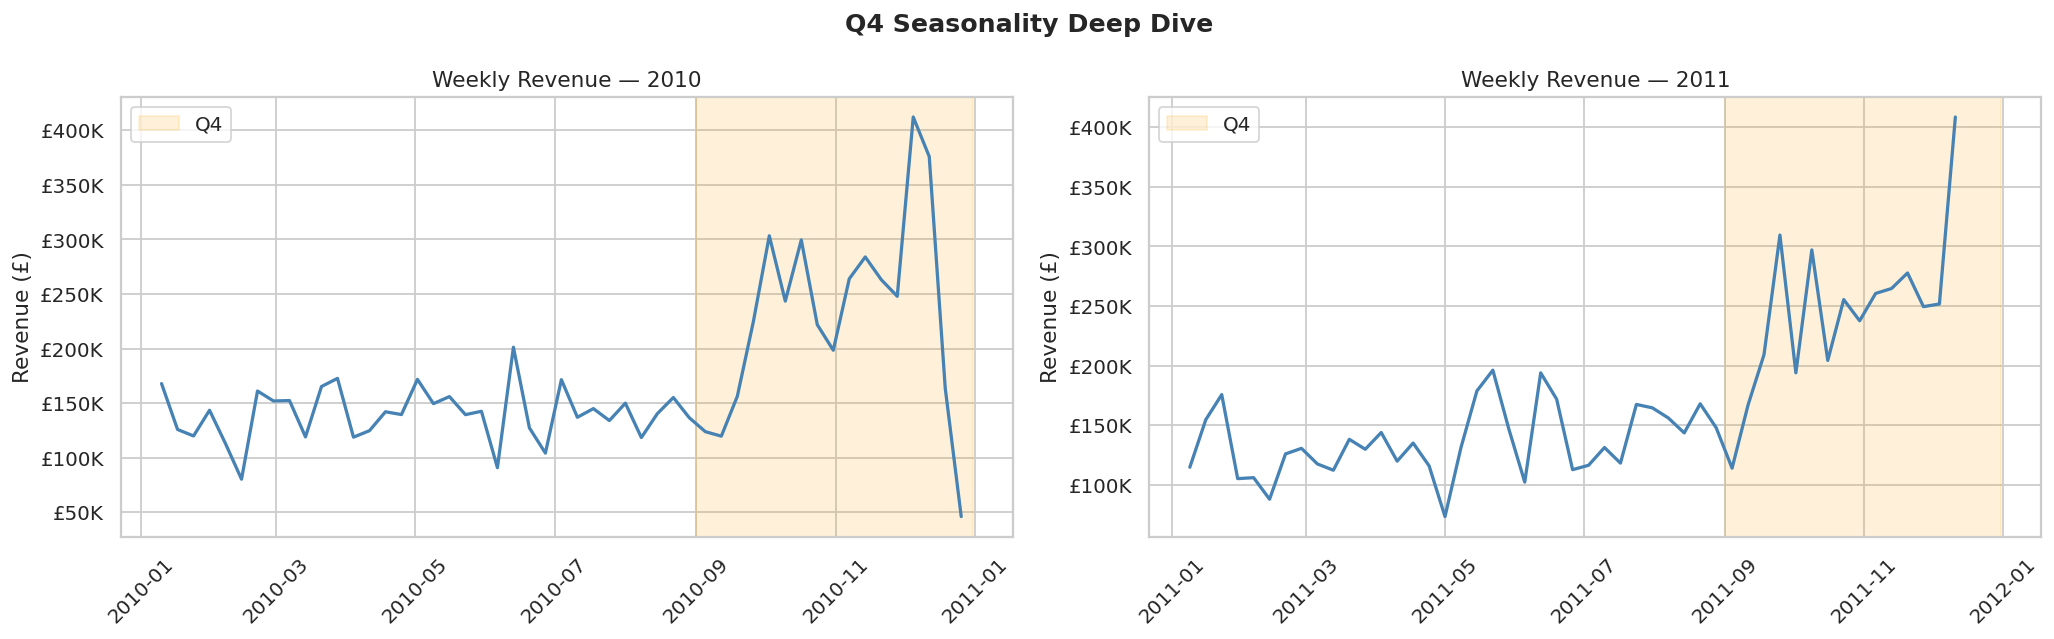

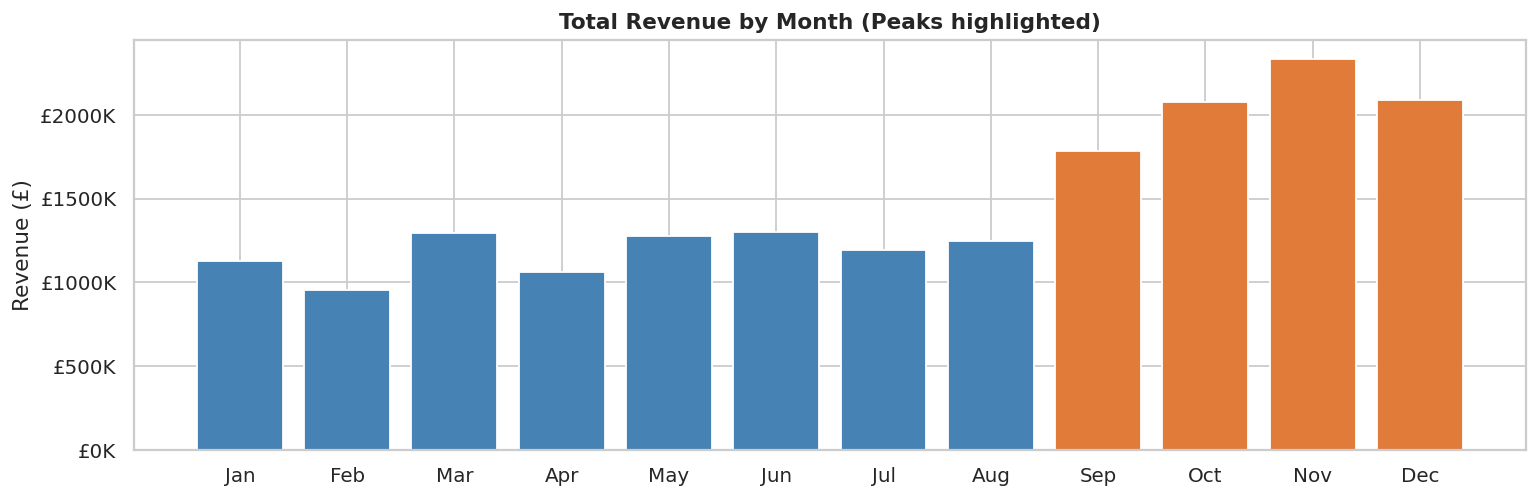

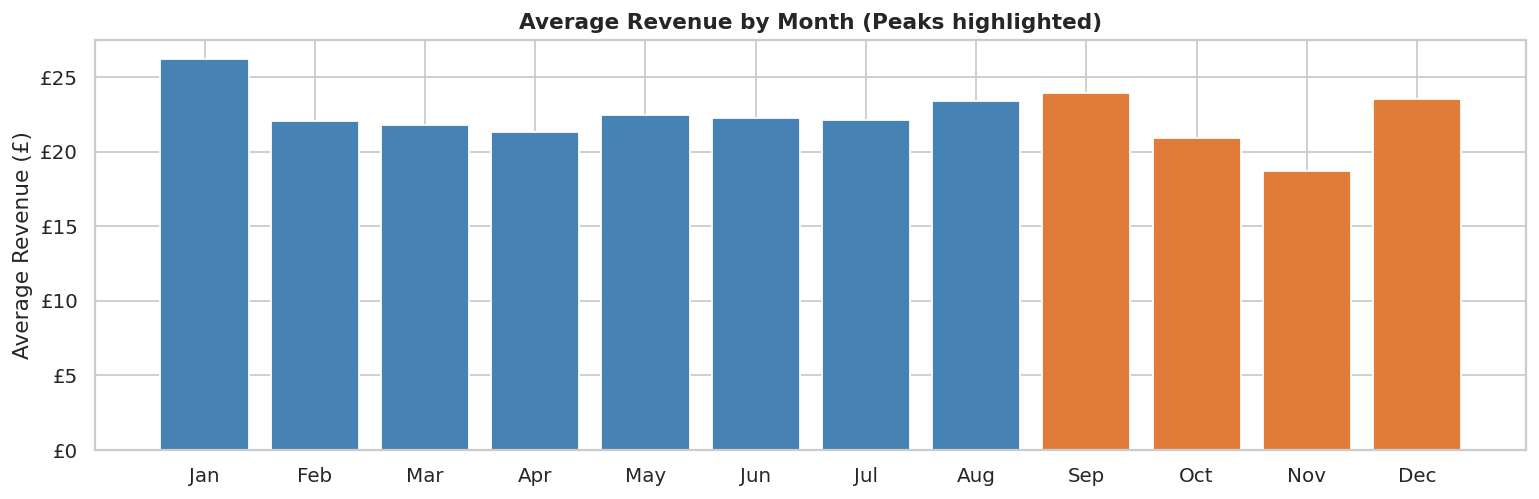

In [34]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['MonthName'] = df_clean['InvoiceDate'].dt.strftime('%b')
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Week'] = df_clean['InvoiceDate'].dt.isocalendar().week.astype(int)

# Weekly revenue for both years separately
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Q4 Seasonality Deep Dive', fontsize=14, fontweight='bold')

for i, year in enumerate([2010, 2011]):
    yearly = df_clean[df_clean['Year'] == year].set_index('InvoiceDate').resample('W')['Revenue'].sum()
    axes[i].plot(yearly.index, yearly.values, color='steelblue', linewidth=1.8)
    # Shade Q4
    q4_start = pd.Timestamp(f'{year}-09-01')
    q4_end   = pd.Timestamp(f'{year}-12-31')
    axes[i].axvspan(q4_start, q4_end, alpha=0.15, color='orange', label='Q4')
    axes[i].set_title(f'Weekly Revenue — {year}')
    axes[i].set_ylabel('Revenue (£)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/seasonality_weekly.png', bbox_inches='tight')
plt.show()

# Total revenue by month (across both years)
monthly_total = df_clean.groupby('Month')['Revenue'].sum()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#e07b39' if m in [9, 10,11,12] else 'steelblue' for m in range(1,13)]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(month_labels, [monthly_total.get(m, 0) for m in range(1,13)], color=colors)
ax.set_title('Total Revenue by Month (Peaks highlighted)', fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/revenue_by_month_total.png', bbox_inches='tight')
plt.show()

# Average revenue by month (across both years)
monthly_avg = df_clean.groupby('Month')['Revenue'].mean()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(month_labels, [monthly_avg.get(m, 0) for m in range(1,13)], color=colors)
ax.set_title('Average Revenue by Month (Peaks highlighted)', fontweight='bold')
ax.set_ylabel('Average Revenue (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}')) # Changed formatter here
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/revenue_by_month_average.png', bbox_inches='tight')
plt.show()

## Top Products

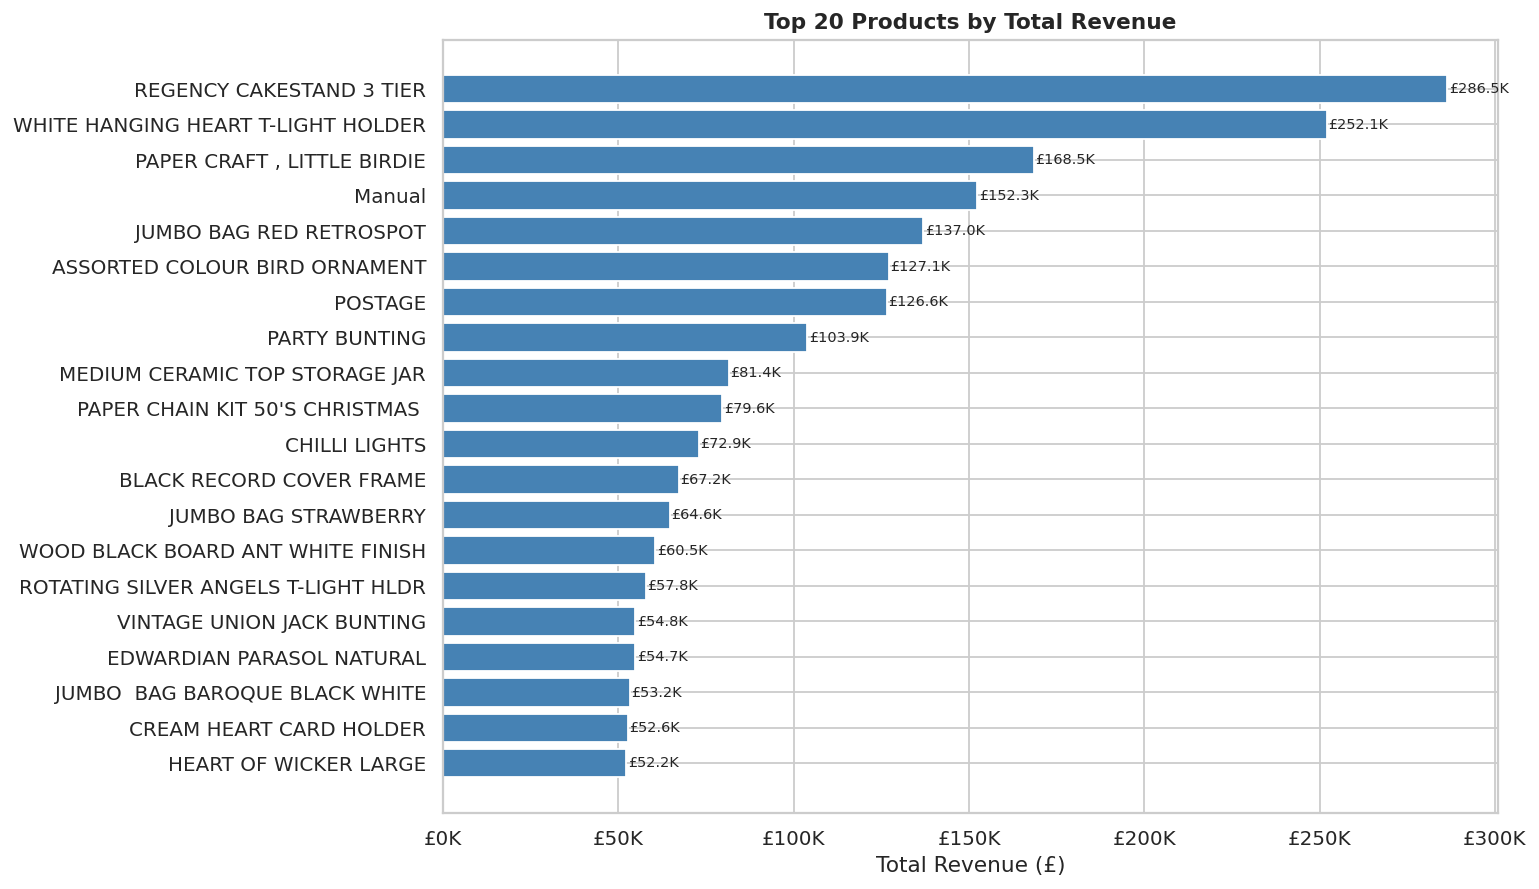

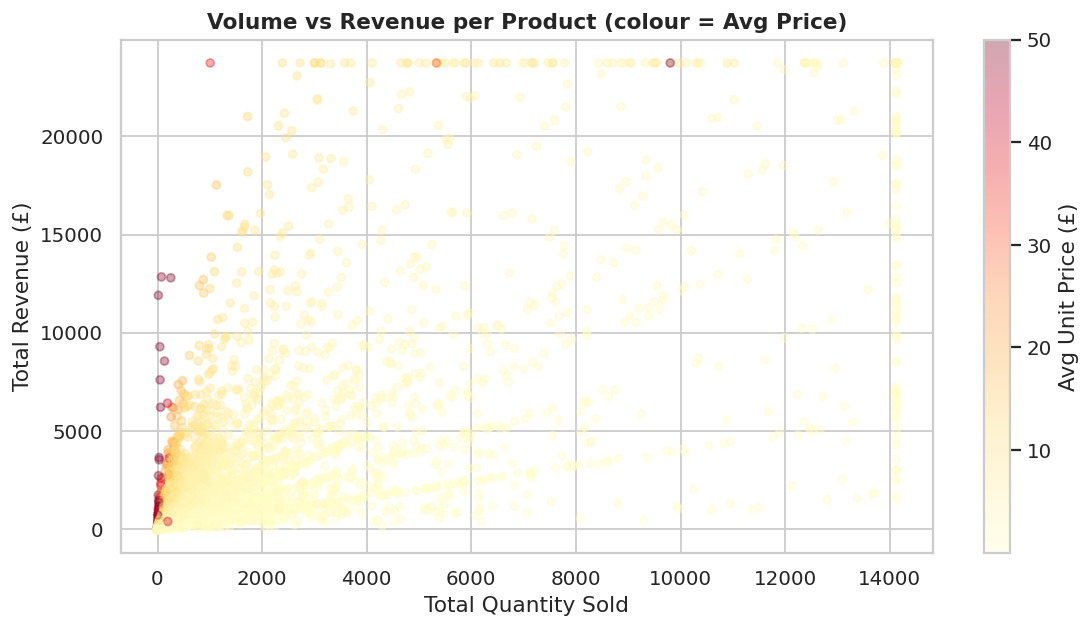

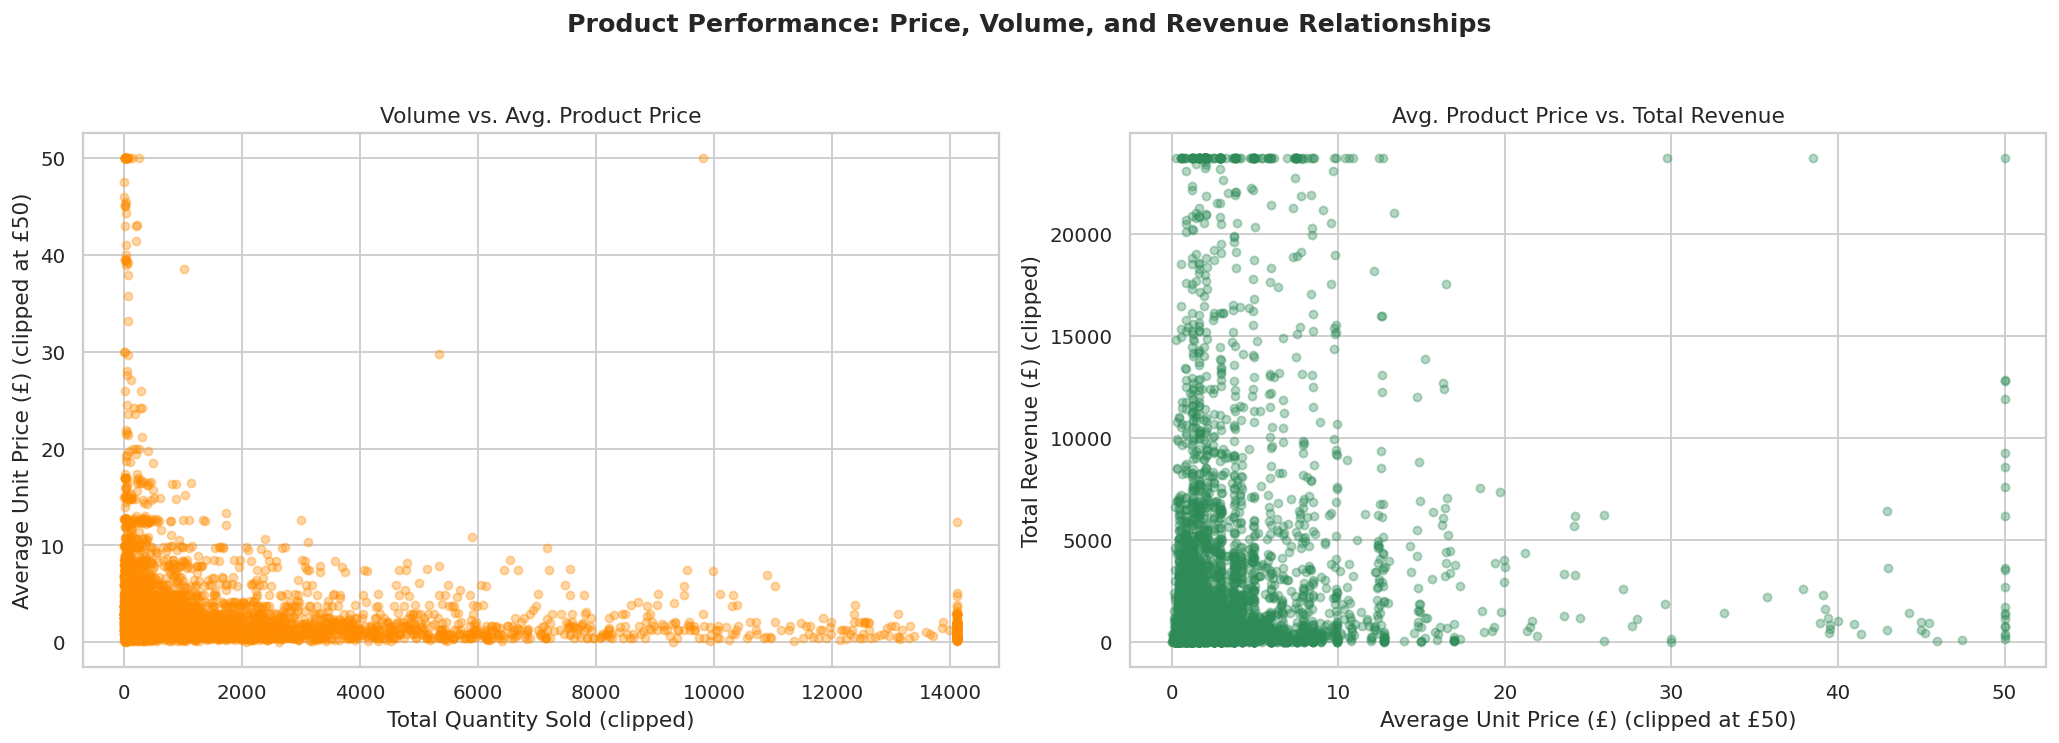

In [31]:
top_products = (df_clean.groupby(['StockCode', 'Description'])['Revenue']
                .sum()
                .reset_index()
                .sort_values('Revenue', ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_products['Description'].str[:40].iloc[::-1],
               top_products['Revenue'].iloc[::-1],
               color='steelblue')
ax.set_title('Top 20 Products by Total Revenue', fontweight='bold')
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

for bar, val in zip(bars, top_products['Revenue'].iloc[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:.1f}K', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/top_products.png', bbox_inches='tight')
plt.show()

# Revenue vs Quantity scatter (are high-volume items high-revenue?)
product_summary = df_clean.groupby('StockCode').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalQty=('Quantity', 'sum'),
    AvgUnitPrice=('Price', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    product_summary['TotalQty'].clip(upper=product_summary['TotalQty'].quantile(0.97)),
    product_summary['TotalRevenue'].clip(upper=product_summary['TotalRevenue'].quantile(0.97)),
    alpha=0.35, c=product_summary['AvgUnitPrice'].clip(upper=50),
    cmap='YlOrRd', s=20
)
plt.colorbar(sc, ax=ax, label='Avg Unit Price (£)')
ax.set_title('Volume vs Revenue per Product (colour = Avg Price)', fontweight='bold')
ax.set_xlabel('Total Quantity Sold')
ax.set_ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/volume_vs_revenue.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Performance: Price, Volume, and Revenue Relationships', fontweight='bold', fontsize=14)

axes[0].scatter(
    product_summary['TotalQty'].clip(upper=product_summary['TotalQty'].quantile(0.97)),
    product_summary['AvgUnitPrice'].clip(upper=50),
    alpha=0.35, s=20, color='darkorange'
)
axes[0].set_title('Volume vs. Avg. Product Price')
axes[0].set_xlabel('Total Quantity Sold (clipped)')
axes[0].set_ylabel('Average Unit Price (£) (clipped at £50)')

axes[1].scatter(
    product_summary['AvgUnitPrice'].clip(upper=50),
    product_summary['TotalRevenue'].clip(upper=product_summary['TotalRevenue'].quantile(0.97)),
    alpha=0.35, s=20, color='seagreen'
)
axes[1].set_title('Avg. Product Price vs. Total Revenue')
axes[1].set_xlabel('Average Unit Price (£) (clipped at £50)')
axes[1].set_ylabel('Total Revenue (£) (clipped)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/price_volume_revenue_relationships.png', bbox_inches='tight')
plt.show()

## High value orders


High-Value Order Threshold (95th percentile): £1,253.78
   Number of high-value orders  : 1,849
   Unique customers in segment  : 521
   Revenue from this segment    : £5,894,352
   Share of total revenue       : 33.2%

--- Top 10 High-Value Customers ---


,Customer ID,TotalSpend,OrderCount,AvgOrderValue,Country
0,18102,582177.38,98,5940.585510,United Kingdom
1,14646,495824.15,79,6276.255063,Netherlands
2,14156,244313.28,41,5958.860488,EIRE
3,17450,240313.73,38,6324.045526,United Kingdom
4,17511,172111.42,48,3585.654583,United Kingdom
5,16446,168469.60,1,168469.600000,United Kingdom
6,13694,150896.14,58,2601.657586,United Kingdom
7,12415,139261.58,12,11605.131667,Australia
8,16684,134951.19,28,4819.685357,United Kingdom
9,14911,105437.28,51,2067.397647,EIRE


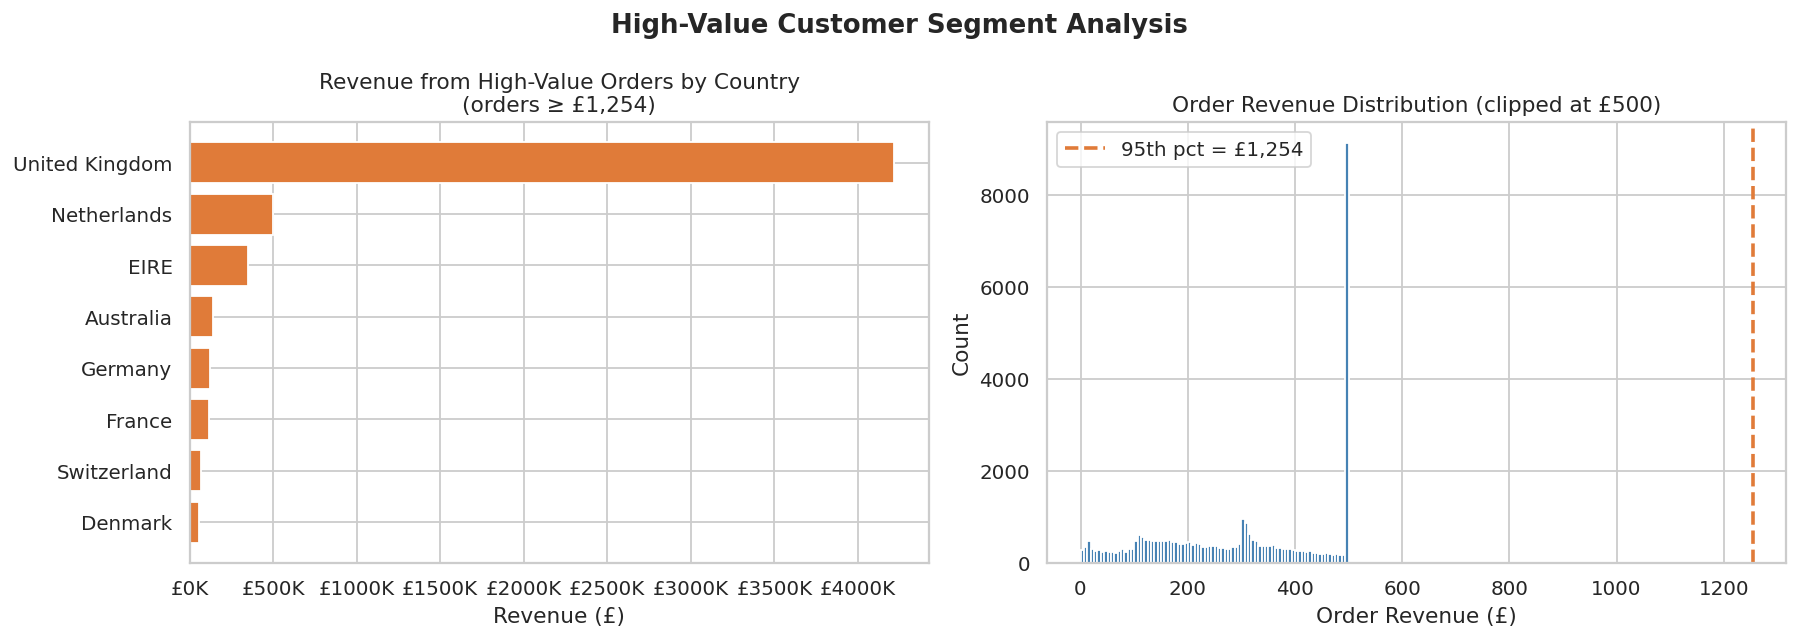

In [33]:
order_revenue = df_clean.groupby('Invoice')['Revenue'].sum().reset_index()
order_revenue.columns = ['Invoice', 'OrderRevenue']
threshold = order_revenue['OrderRevenue'].quantile(0.95)

high_value_invoices = order_revenue[order_revenue['OrderRevenue'] >= threshold]['Invoice']
hv_df = df_clean[df_clean['Invoice'].isin(high_value_invoices)]

print(f"\nHigh-Value Order Threshold (95th percentile): £{threshold:,.2f}")
print(f"   Number of high-value orders  : {len(high_value_invoices):,}")
print(f"   Unique customers in segment  : {hv_df['Customer ID'].nunique():,}")
print(f"   Revenue from this segment    : £{hv_df['Revenue'].sum():,.0f}")
print(f"   Share of total revenue       : {hv_df['Revenue'].sum() / df_clean['Revenue'].sum() * 100:.1f}%")

# Customer view
hv_customers = (hv_df.groupby('Customer ID')
                .agg(
                    TotalSpend=('Revenue', 'sum'),
                    OrderCount=('Invoice', 'nunique'),
                    AvgOrderValue=('Revenue', lambda x: x.groupby(hv_df.loc[x.index, 'Invoice']).sum().mean()),
                    Country=('Country', lambda x: x.mode()[0])
                )
                .sort_values('TotalSpend', ascending=False)
                .reset_index())

print(f"\n--- Top 10 High-Value Customers ---")
display(hv_customers.head(10))

# Country breakdown of high-value orders
hv_country = hv_df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('High-Value Customer Segment Analysis', fontweight='bold')

axes[0].barh(hv_country.index[::-1], hv_country.values[::-1], color='#e07b39')
axes[0].set_title(f'Revenue from High-Value Orders by Country\n(orders ≥ £{threshold:,.0f})')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))

axes[1].hist(order_revenue['OrderRevenue'].clip(upper=500), bins=80,
             color='steelblue', edgecolor='white')
axes[1].axvline(threshold, color='#e07b39', linewidth=2, linestyle='--',
                label=f'95th pct = £{threshold:,.0f}')
axes[1].set_title('Order Revenue Distribution (clipped at £500)')
axes[1].set_xlabel('Order Revenue (£)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visualshigh_value_segment.png', bbox_inches='tight')
plt.show()

# Feature Engineering

## Setup & Prep

In [37]:
# Churn is defined using obervation and prediction window (train test split)
# everything before cutoff date is obervsed, 90 days after cutoff is prediction.
# customer is churned if no purchases made in pred window

snapshot_date = df_clean['InvoiceDate'].max()          # last date in data
cutoff_date = snapshot_date - pd.Timedelta(days=90)  # 90-day prediction window

print(f"Dataset ends      : {snapshot_date.date()}")
print(f"Cutoff date       : {cutoff_date.date()}")
print(f"Observation window: {df_clean['InvoiceDate'].min().date()} - {cutoff_date.date()}")
print(f"Prediction window : {cutoff_date.date()} → {snapshot_date.date()}")

# split between observation and prediction
df_obs    = df_clean[df_clean['InvoiceDate'] <= cutoff_date].copy()
df_future = df_clean[df_clean['InvoiceDate'] >  cutoff_date].copy()

# customers who purchased in the future window = NOT churned (label 0)
future_customers = set(df_future['Customer ID'].unique())

print(f"\nCustomers in observation window : {df_obs['Customer ID'].nunique():,}")
print(f"Customers active in future 90d  : {len(future_customers):,}")


Dataset ends      : 2011-12-09
Cutoff date       : 2011-09-10
Observation window: 2009-12-01 - 2011-09-10
Prediction window : 2011-09-10 → 2011-12-09

Customers in observation window : 5,281
Customers active in future 90d  : 2,889


## Invoice level summary

In [38]:
invoice_summary = (df_obs.groupby(['Customer ID', 'Invoice'])
                   .agg(
                       InvoiceDate=('InvoiceDate', 'max'),
                       OrderRevenue=('Revenue', 'sum'),
                       ItemCount=('Quantity', 'sum')
                   )
                   .reset_index())

## Cancellation rate

In [39]:
cancel_df = pd.concat([df1, df2], ignore_index=True)
cancel_df = cancel_df.dropna(subset=['Customer ID'])
cancel_df['Customer ID'] = cancel_df['Customer ID'].astype(int).astype(str)
cancel_df['IsCancelled'] = cancel_df['Invoice'].astype(str).str.startswith('C').astype(int)

cancel_rate = (cancel_df.groupby('Customer ID')
               .agg(
                   TotalTransactions=('Invoice', 'count'),
                   Cancellations=('IsCancelled', 'sum')
               )
               .reset_index())
cancel_rate['CancellationRate'] = (cancel_rate['Cancellations'] /
                                   cancel_rate['TotalTransactions']).round(4)

## RFM + behaviour feature

In [40]:
rfm = (df_obs.groupby('Customer ID')
       .agg(
           LastPurchaseDate=('InvoiceDate', 'max'),
           FirstPurchaseDate=('InvoiceDate', 'min'),
           Frequency=('Invoice', 'nunique'),
           Monetary=('Revenue', 'sum'),
           UniqueProducts=('StockCode', 'nunique'),
           UniqueCountries=('Country', 'nunique'),
           TotalItems=('Quantity', 'sum')
       )
       .reset_index())

# Recency: days since last purchase (relative to cutoff, not snapshot)
rfm['Recency'] = (cutoff_date - rfm['LastPurchaseDate']).dt.days

# Tenure: how long have they been a customer (days)
rfm['Tenure'] = (rfm['LastPurchaseDate'] - rfm['FirstPurchaseDate']).dt.days

# Average Order Value
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# Average items per order
rfm['AvgItemsPerOrder'] = rfm['TotalItems'] / rfm['Frequency']

# Average days between orders (purchasing rhythm)
# Only meaningful for customers with 2+ orders
rfm['AvgDaysBetweenOrders'] = np.where(
    rfm['Frequency'] > 1,
    rfm['Tenure'] / (rfm['Frequency'] - 1),
    rfm['Tenure']  # for 1-time buyers, use tenure as proxy
)

# Q4 buyer flag: did they purchase in Sep-Dec?
q4_buyers = set(
    df_obs[df_obs['InvoiceDate'].dt.month.isin([9, 10, 11, 12])]['Customer ID'].unique()
)
rfm['IsQ4Buyer'] = rfm['Customer ID'].isin(q4_buyers).astype(int)

# UK customer flag (dominant segment)
uk_customers = set(df_obs[df_obs['Country'] == 'United Kingdom']['Customer ID'].unique())
rfm['IsUK'] = rfm['Customer ID'].isin(uk_customers).astype(int)

# High-value customer flag (from our EDA — top 5% order value)
rfm['IsHighValue'] = rfm['Customer ID'].isin(
    hv_customers['Customer ID'].astype(str)
).astype(int)

# Merge cancellation rate
rfm = rfm.merge(cancel_rate[['Customer ID', 'CancellationRate']],
                on='Customer ID', how='left')
rfm['CancellationRate'] = rfm['CancellationRate'].fillna(0)

## Churn label

In [41]:
rfm['Churned'] = (~rfm['Customer ID'].isin(future_customers)).astype(int)

print("\n--- RFM Feature Table Sample ---")
display(rfm.head(10))

print(f"\n--- Churn Label Distribution ---")
churn_counts = rfm['Churned'].value_counts()
churn_pct    = rfm['Churned'].value_counts(normalize=True) * 100
print(f"Not Churned (0) : {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"Churned     (1) : {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")


--- RFM Feature Table Sample ---


,Customer ID,LastPurchaseDate,FirstPurchaseDate,Frequency,Monetary,UniqueProducts,UniqueCountries,TotalItems,Recency,Tenure,AOV,AvgItemsPerOrder,AvgDaysBetweenOrders,IsQ4Buyer,IsUK,IsHighValue,CancellationRate,Churned
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,27,1,74285,235,400,6463.038333,6190.416667,36.363636,1,1,1,0.2917,1
1,12347,2011-08-02 08:48:00,2010-10-31 14:20:00,6,4114.18,107,1,2418,39,274,685.696667,403.000000,54.800000,1,0,1,0.0000,0
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1709.40,25,1,2497,158,189,427.350000,624.250000,63.000000,1,0,0,0.0000,0
3,12349,2010-10-28 08:23:00,2010-04-29 13:20:00,3,2671.14,90,1,993,317,181,890.380000,331.000000,90.500000,1,0,1,0.0278,0
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,17,1,197,219,0,334.400000,197.000000,0.000000,0,0,0,0.0000,1
5,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,300.93,21,1,261,284,0,300.930000,261.000000,0.000000,1,0,0,0.0000,1
6,12352,2011-03-22 16:08:00,2010-11-12 10:20:00,7,1905.61,38,1,442,171,130,272.230000,63.142857,21.666667,1,0,0,0.0885,0
7,12353,2011-05-19 17:47:00,2010-10-27 12:44:00,2,406.76,23,1,212,113,204,203.380000,106.000000,204.000000,1,0,0,0.0000,1
8,12354,2011-04-21 13:11:00,2011-04-21 13:11:00,1,1079.40,58,1,530,141,0,1079.400000,530.000000,0.000000,0,0,0,0.0000,1
9,12355,2011-05-09 13:49:00,2010-05-21 11:59:00,2,947.61,35,1,543,123,353,473.805000,271.500000,353.000000,0,0,0,0.0000,1



--- Churn Label Distribution ---
Not Churned (0) : 2,292  (43.4%)
Churned     (1) : 2,989  (56.6%)


## Feature plot

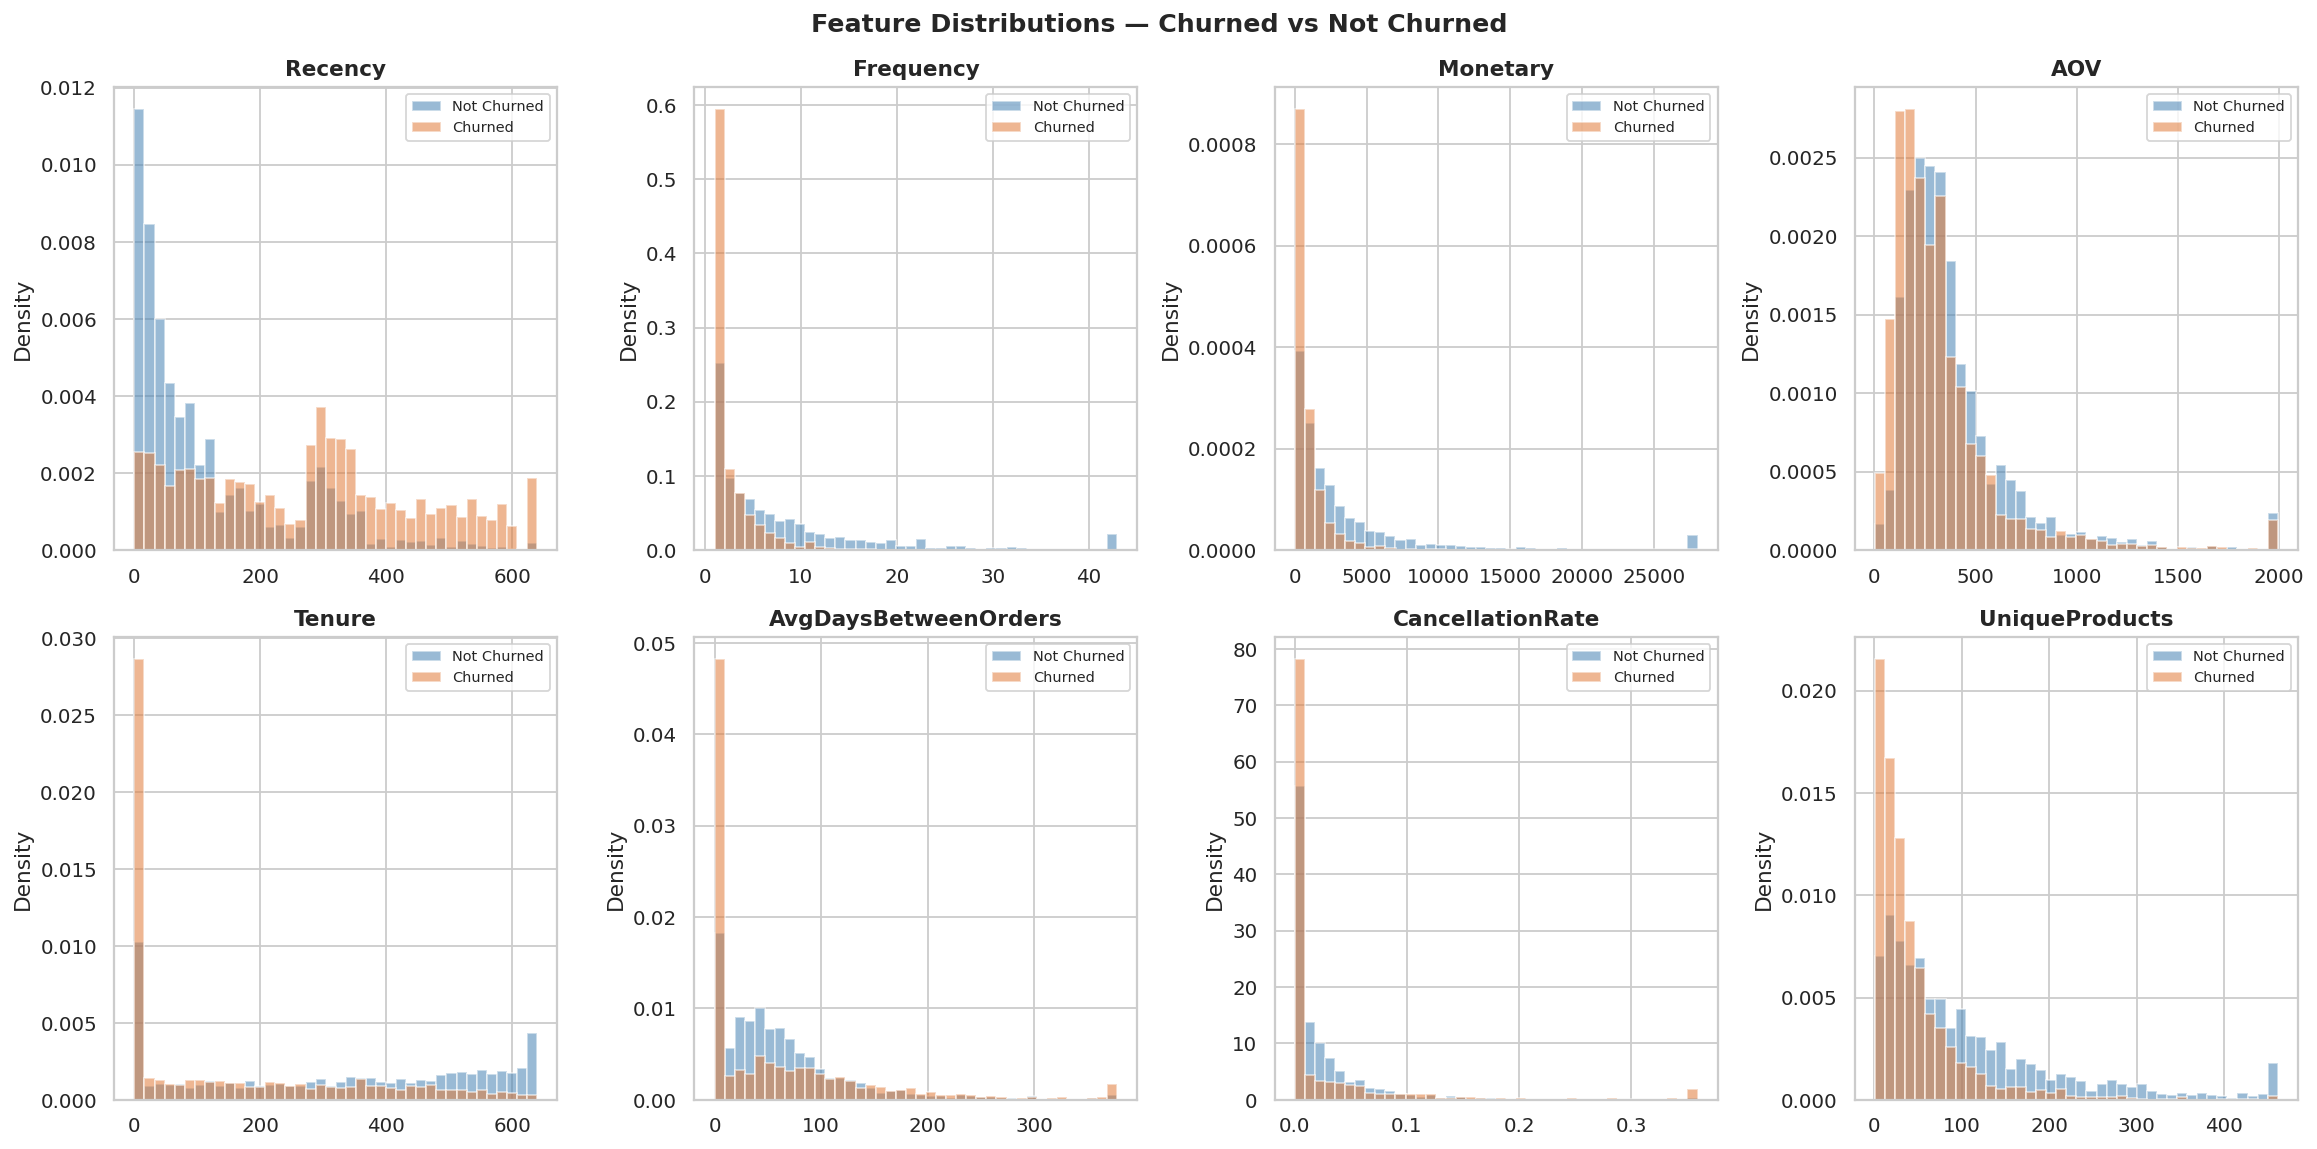

In [43]:
features_to_plot = ['Recency', 'Frequency', 'Monetary', 'AOV',
                    'Tenure', 'AvgDaysBetweenOrders', 'CancellationRate',
                    'UniqueProducts']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Feature Distributions — Churned vs Not Churned',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

colors = {0: 'steelblue', 1: '#e07b39'}
labels = {0: 'Not Churned', 1: 'Churned'}

for i, feat in enumerate(features_to_plot):
    for churn_val in [0, 1]:
        subset = rfm[rfm['Churned'] == churn_val][feat]
        # Clip at 99th percentile to avoid extreme outliers distorting plots
        clip_val = rfm[feat].quantile(0.99)
        subset_clipped = subset.clip(upper=clip_val)
        axes[i].hist(subset_clipped, bins=40, alpha=0.55,
                     color=colors[churn_val], label=labels[churn_val],
                     density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/feature_distributions.png', bbox_inches='tight')
plt.show()

## Coorelation

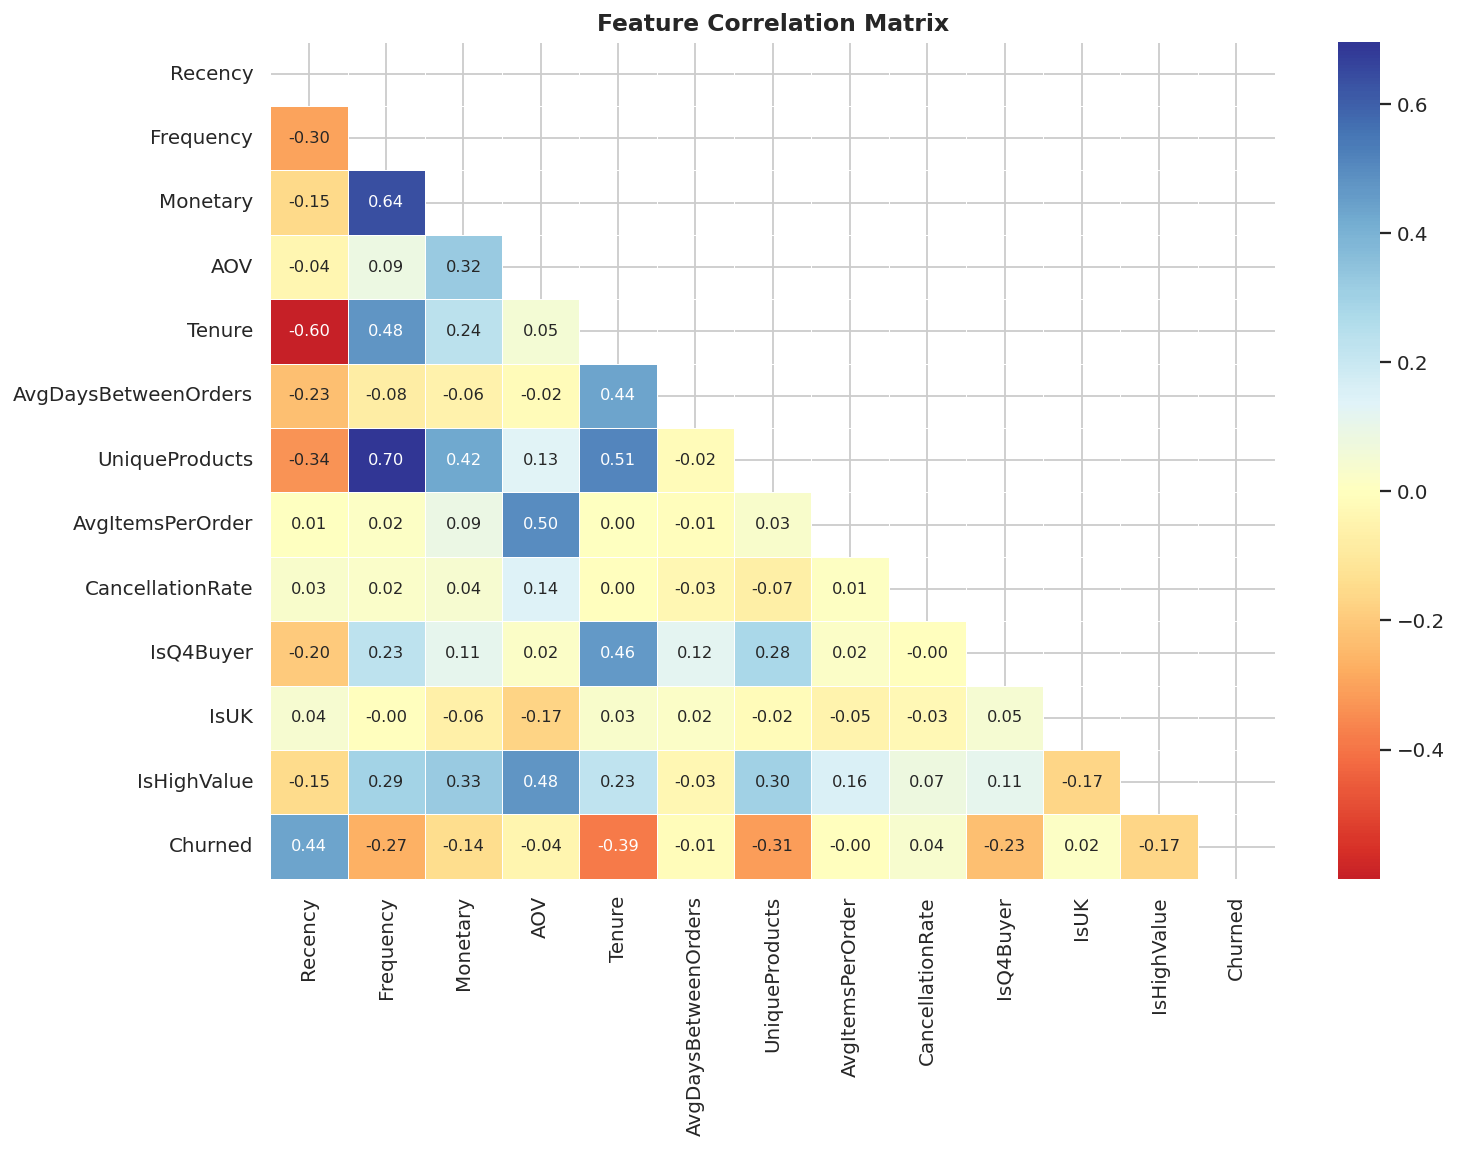

In [44]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure',
                'AvgDaysBetweenOrders', 'UniqueProducts', 'AvgItemsPerOrder',
                'CancellationRate', 'IsQ4Buyer', 'IsUK', 'IsHighValue', 'Churned']

fig, ax = plt.subplots(figsize=(12, 9))
corr = rfm[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Churn rate by segment


--- Churn Rate by Segment ---


,Segment,Customers,Churned,Churn Rate (%),Avg Revenue (£)
0,Overall,5281,2989,56.6,2705.0
1,High-Value,495,153,30.9,15406.0
2,UK Customers,4814,2737,56.9,2454.0
3,Non-UK,467,252,54.0,5294.0
4,Q4 Buyers,3438,1658,48.2,3731.0
5,Non-Q4 Buyers,1843,1331,72.2,791.0
6,Repeat Buyers,3705,1731,46.7,3709.0
7,One-Time Buyers,1576,1258,79.8,347.0


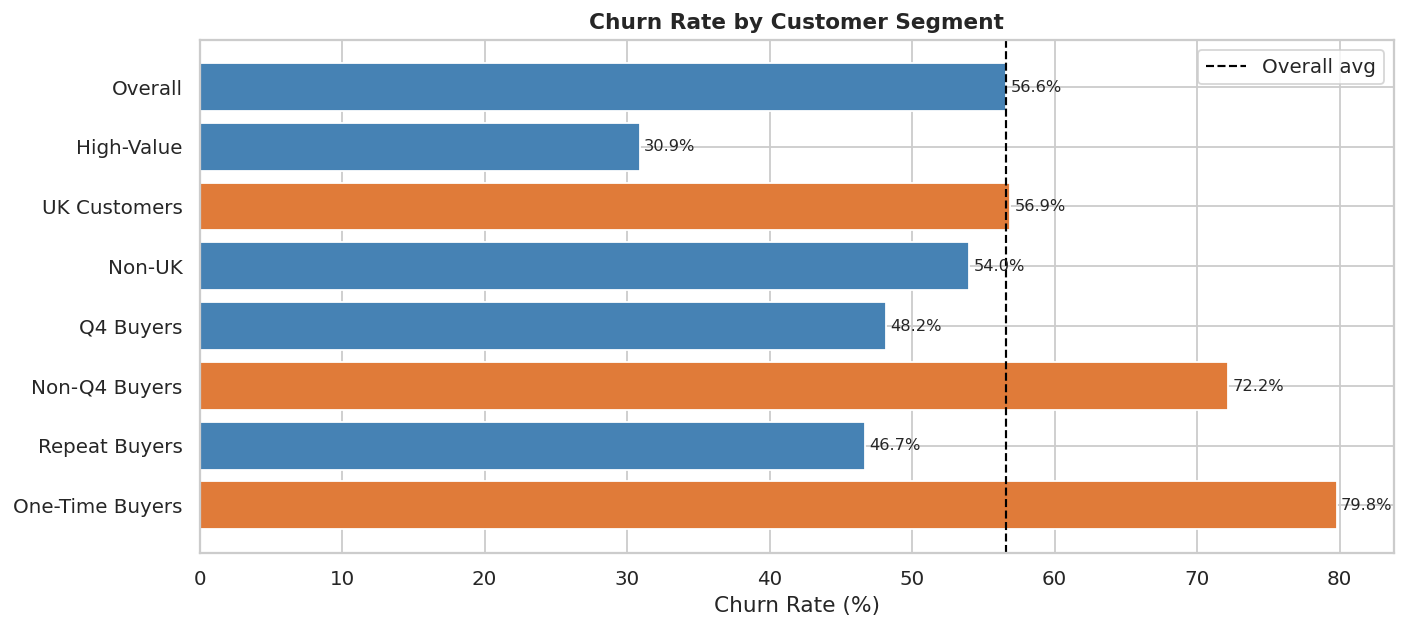

   RFM table shape : (5281, 18)
   Features built  : 12


In [48]:
print("\n--- Churn Rate by Segment ---")
segments = {
    'Overall'          : rfm,
    'High-Value'       : rfm[rfm['IsHighValue'] == 1],
    'UK Customers'     : rfm[rfm['IsUK'] == 1],
    'Non-UK'           : rfm[rfm['IsUK'] == 0],
    'Q4 Buyers'        : rfm[rfm['IsQ4Buyer'] == 1],
    'Non-Q4 Buyers'    : rfm[rfm['IsQ4Buyer'] == 0],
    'Repeat Buyers'    : rfm[rfm['Frequency'] > 1],
    'One-Time Buyers'  : rfm[rfm['Frequency'] == 1],
}

seg_rows = []
for name, seg_df in segments.items():
    n           = len(seg_df)
    churned     = seg_df['Churned'].sum()
    churn_rate  = churned / n * 100
    avg_revenue = seg_df['Monetary'].mean()
    seg_rows.append({
        'Segment'         : name,
        'Customers'       : n,
        'Churned'         : churned,
        'Churn Rate (%)'  : round(churn_rate, 1),
        'Avg Revenue (£)' : round(avg_revenue, 0)
    })

seg_summary = pd.DataFrame(seg_rows)
display(seg_summary)

# Churn rate by segment
fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#e07b39' if r > seg_summary.loc[0, 'Churn Rate (%)']
              else 'steelblue' for r in seg_summary['Churn Rate (%)']]
bars = ax.barh(seg_summary['Segment'][::-1],
               seg_summary['Churn Rate (%)'][::-1],
               color=bar_colors[::-1])
ax.axvline(seg_summary.loc[0, 'Churn Rate (%)'],
           color='black', linestyle='--', linewidth=1.2, label='Overall avg')
ax.set_title('Churn Rate by Customer Segment', fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
ax.legend()
for bar, val in zip(bars, seg_summary['Churn Rate (%)'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/eCommerce Churn Prediction/visuals/churn_by_segment.png', bbox_inches='tight')
plt.show()

print(f"   RFM table shape : {rfm.shape}")
print(f"   Features built  : {len(feature_cols) - 1}")